# Data Quality Assessment (DQA)

## Country-Level Economic Stress Monitoring and Predictive Analytics System

### Objective

Assess the quality of the datasets to ensure they are suitable for:

- Economic Stress Analysis
- Regional Analysis
- Statistical Analysis
- Country Clustering
- Geospatial Visualization
- Dashboard Development

### Data Quality Dimensions

- Completeness
- Validity
- Consistency
- Uniqueness
- Accuracy
- Integrity

In [1]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [4]:
# =====================================================
# LOAD DATASETS
# =====================================================

country_year = pd.read_csv("C:/Users/saksh/Desktop/country-economic-stress-analysis/data/country_year_indicators.csv")

country_metadata = pd.read_csv("C:/Users/saksh/Desktop/country-economic-stress-analysis/data/country_metadata.csv")

economic_stress = pd.read_csv("C:/Users/saksh/Desktop/country-economic-stress-analysis/data/economic_stress_score.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [5]:
# =====================================================
# DATASET INVENTORY
# =====================================================

datasets = {
    "country_year": country_year,
    "country_metadata": country_metadata,
    "economic_stress": economic_stress
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 40)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])


COUNTRY_YEAR
----------------------------------------
Rows: 14322
Columns: 18

COUNTRY_METADATA
----------------------------------------
Rows: 217
Columns: 7

ECONOMIC_STRESS
----------------------------------------
Rows: 14322
Columns: 12


In [6]:
# =====================================================
# DUPLICATE CHECK
# =====================================================

for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()}")

country_year: 0
country_metadata: 0
economic_stress: 0


## Missing Value Analysis

This section evaluates data completeness by identifying missing values across all datasets and determining their potential impact on analysis.

In [7]:
# =====================================================
# MISSING VALUES - COUNTRY YEAR DATASET
# =====================================================

missing_country_year = pd.DataFrame({
    'Missing Values': country_year.isnull().sum(),
    'Missing Percentage': round(
        (country_year.isnull().sum() / len(country_year)) * 100,
        2
    )
})

missing_country_year = missing_country_year.sort_values(
    by='Missing Percentage',
    ascending=False
)

missing_country_year[
    missing_country_year['Missing Values'] > 0
]


,Missing Values,Missing Percentage
dietary_energy_supply_adequacy,10491,73.25
unemployment,7791,54.40
inflation,5351,37.36
cereal_yield,3992,27.87
cereal_production_tonnes,3942,27.52
food_production_index,3311,23.12
gdp_growth,3108,21.70
gdp_per_capita,2753,19.22
agricultural_land_pct,2262,15.79
economic_stress_score,1560,10.89


In [8]:
# =====================================================
# MISSING VALUES - COUNTRY METADATA
# =====================================================

missing_metadata = pd.DataFrame({
    'Missing Values': country_metadata.isnull().sum(),
    'Missing Percentage': round(
        (country_metadata.isnull().sum() / len(country_metadata)) * 100,
        2
    )
})

missing_metadata

,Missing Values,Missing Percentage
country_code,0,0.00
country_name,0,0.00
iso3,0,0.00
region,0,0.00
income_group,0,0.00
latitude,6,2.76
longitude,6,2.76


In [9]:
# =====================================================
# MISSING VALUES - ECONOMIC STRESS
# =====================================================

missing_stress = pd.DataFrame({
    'Missing Values': economic_stress.isnull().sum(),
    'Missing Percentage': round(
        (economic_stress.isnull().sum() / len(economic_stress)) * 100,
        2
    )
})

missing_stress = missing_stress.sort_values(
    by='Missing Percentage',
    ascending=False
)

missing_stress[missing_stress['Missing Values'] > 0]

,Missing Values,Missing Percentage
unemployment_score,7791,54.40
inflation_score,5351,37.36
gdp_growth_score,3108,21.70
food_pressure_score,2936,20.50
income_vulnerability_score,2753,19.22
final_economic_stress_score,1560,10.89
stress_category,1560,10.89


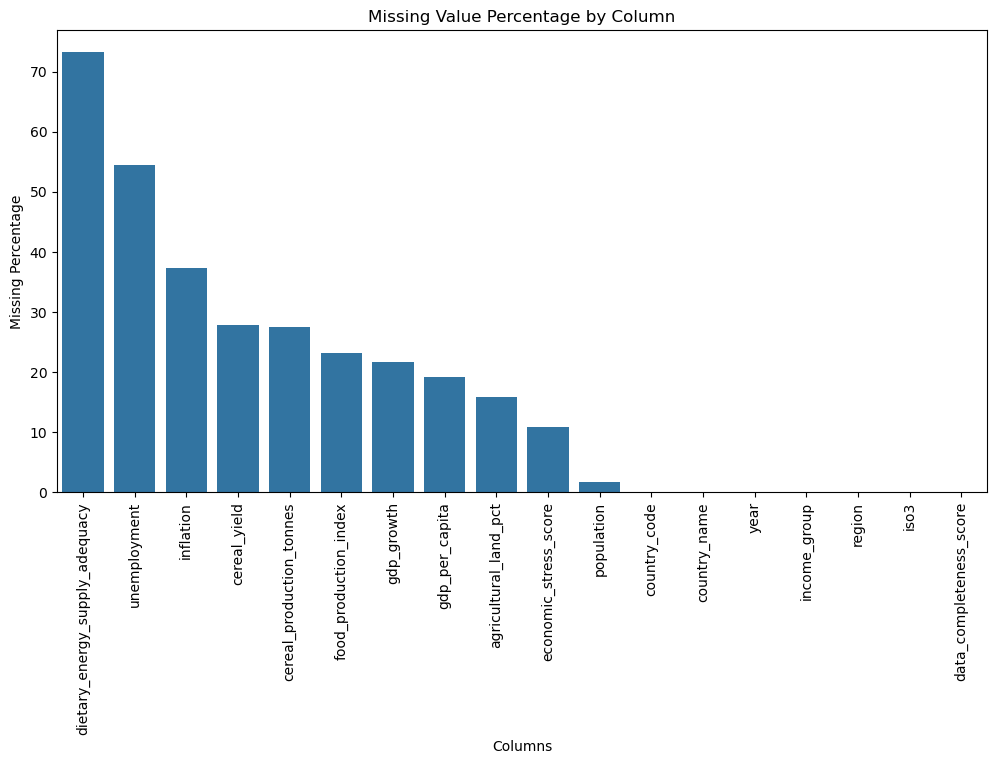

In [10]:
# =====================================================
# MISSING VALUE PERCENTAGE
# =====================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_country_year.index,
    y=missing_country_year['Missing Percentage']
)

plt.xticks(rotation=90)

plt.title("Missing Value Percentage by Column")

plt.ylabel("Missing Percentage")

plt.xlabel("Columns")

plt.show()

## Primary Key Validation

Validate uniqueness of business keys used for joining datasets.

In [11]:
# =====================================================
# PRIMARY KEY VALIDATION
# =====================================================

duplicate_country_year = country_year.duplicated(
    subset=['country_code', 'year']
).sum()

print("Duplicate Country-Year Keys:", duplicate_country_year)

Duplicate Country-Year Keys: 0


In [12]:
duplicate_stress = economic_stress.duplicated(
    subset=['country_code', 'year']
).sum()

print("Duplicate Country-Year Keys (Stress Dataset):",
      duplicate_stress)

Duplicate Country-Year Keys (Stress Dataset): 0


## Descriptive Statistics and Validity Checks

This section evaluates numerical variables to identify unusual values, invalid ranges, and potential outliers that may impact analysis.

In [13]:
# =====================================================
# DESCRIPTIVE STATISTICS
# =====================================================

country_year.describe().T

,count,mean,std,min,25%,50%,75%,max
year,14322.0,1.992500e+03,1.905104e+01,1960.000000,1976.000000,1.992500e+03,2.009000e+03,2.025000e+03
gdp_growth,11214.0,3.626468e+00,6.791194e+00,-64.047107,1.173154,3.761785e+00,6.252768e+00,1.499730e+02
inflation,8971.0,2.280319e+01,3.193164e+02,-17.640424,2.129506,4.803706e+00,1.006558e+01,2.377313e+04
unemployment,6531.0,8.074188e+00,6.078864e+00,0.100000,3.636000,6.319000e+00,1.093700e+01,3.880000e+01
gdp_per_capita,11569.0,9.658042e+03,1.903456e+04,11.801322,613.038043,2.195449e+03,9.404540e+03,2.880014e+05
population,14075.0,2.531041e+07,1.056614e+08,2715.000000,496939.000000,4.252876e+06,1.396688e+07,1.450936e+09
food_production_index,11011.0,7.766438e+01,5.285098e+01,3.080000,46.160000,7.716000e+01,9.927000e+01,7.544800e+02
cereal_yield,10330.0,2.562938e+03,2.343863e+03,0.100000,1136.400000,1.900050e+03,3.391450e+03,3.676190e+04
cereal_production_tonnes,10380.0,1.151620e+07,4.564354e+07,0.000000,138350.000000,1.073335e+06,5.111468e+06,6.513557e+08
agricultural_land_pct,12060.0,3.572312e+01,2.204989e+01,0.069900,16.694175,3.624370e+01,5.284650e+01,9.280440e+01


## Key Findings

1. Dataset contains 14,322 country-year records spanning 1960–2025.

2. Significant missing values exist in:
   - Dietary Energy Supply Adequacy (~73% missing)
   - Unemployment
   - Inflation

3. Inflation contains extreme outliers with a maximum value of 237,731%, indicating potential hyperinflation events.

4. GDP Growth contains extreme values ranging from -64% to 150%.

5. Economic Stress Score and Data Completeness Score pass range validation (0–100).

6. Agricultural Land Percentage values fall within expected business limits.

7. Additional outlier analysis is recommended before modeling.

In [15]:
# =====================================================
# KEY ECONOMIC INDICATORS
# =====================================================

economic_cols = [
    'gdp_growth',
    'inflation',
    'unemployment',
    'gdp_per_capita',
    'economic_stress_score'
]

country_year[economic_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
gdp_growth,11214.0,3.626468,6.791194,-64.047107,1.173154,3.761785,6.252768,149.972963
inflation,8971.0,22.803193,319.316354,-17.640424,2.129506,4.803706,10.065584,23773.131770
unemployment,6531.0,8.074188,6.078864,0.100000,3.636000,6.319000,10.937000,38.800000
gdp_per_capita,11569.0,9658.041742,19034.560732,11.801322,613.038043,2195.448900,9404.540059,288001.433400
economic_stress_score,12762.0,49.822761,17.273854,0.000000,37.902500,49.620000,61.607500,100.000000


In [16]:
# =====================================================
# NUMERICAL VARIABLE RANGE VALIDATION
# =====================================================

range_check = pd.DataFrame({
    'Minimum Value': country_year.select_dtypes(include=['int64', 'float64']).min(),
    'Maximum Value': country_year.select_dtypes(include=['int64', 'float64']).max()
})

range_check

,Minimum Value,Maximum Value
year,1960.000000,2.025000e+03
gdp_growth,-64.047107,1.499730e+02
inflation,-17.640424,2.377313e+04
unemployment,0.100000,3.880000e+01
gdp_per_capita,11.801322,2.880014e+05
population,2715.000000,1.450936e+09
food_production_index,3.080000,7.544800e+02
cereal_yield,0.100000,3.676190e+04
cereal_production_tonnes,0.000000,6.513557e+08
agricultural_land_pct,0.069900,9.280440e+01


## Outlier Assessment

This section identifies extreme values within key economic indicators that may influence analysis results.

### Method Used

- Boxplot Analysis
- Interquartile Range (IQR) Method

### Variables Assessed

- GDP Growth
- Inflation
- Unemployment
- GDP per Capita
- Economic Stress Score

### Objective

To identify potential outliers and determine whether they represent genuine economic events or data quality issues.

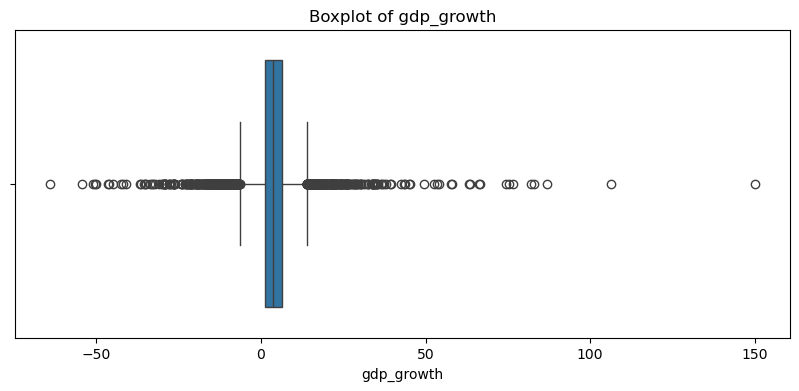

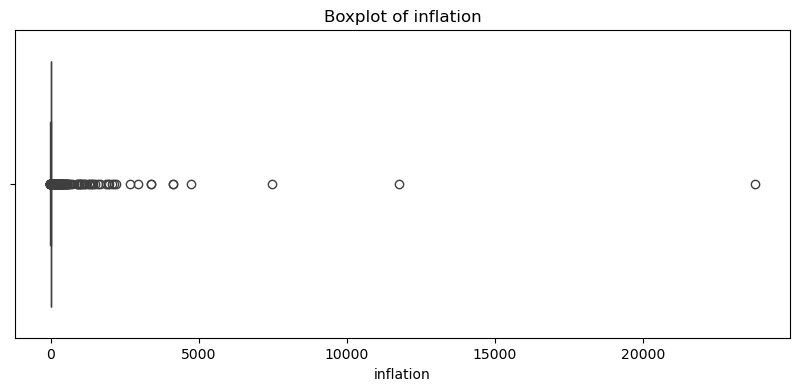

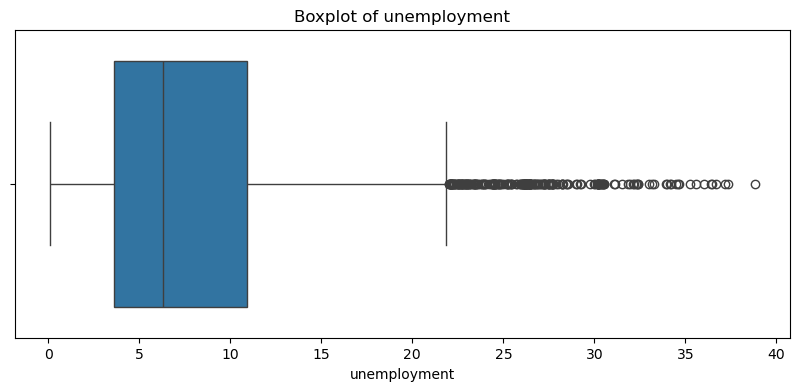

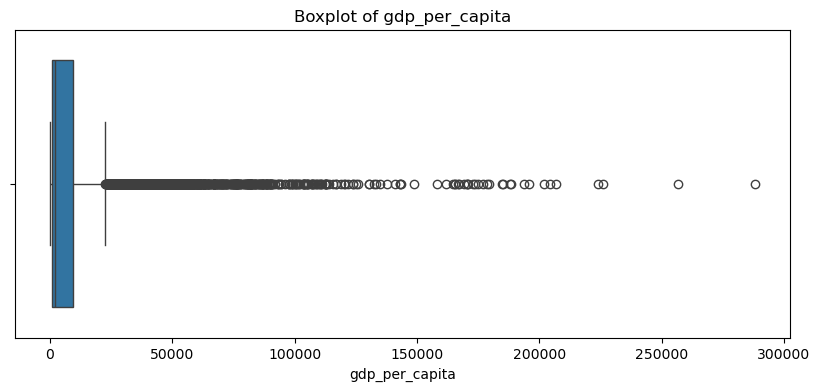

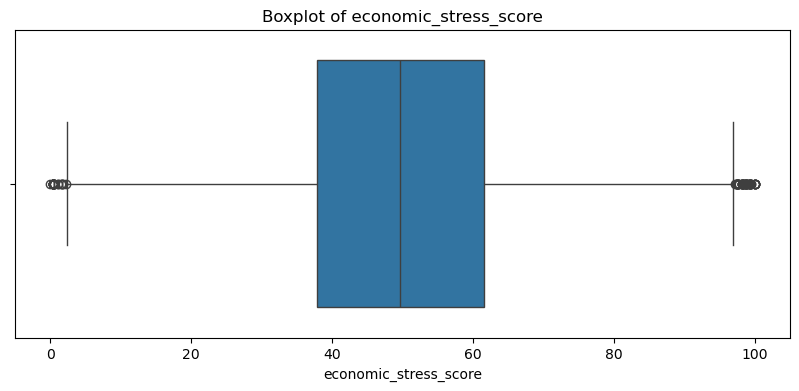

In [17]:
# =====================================================
# OUTLIER VISUALIZATION
# =====================================================

numeric_cols = [
    'gdp_growth',
    'inflation',
    'unemployment',
    'gdp_per_capita',
    'economic_stress_score'
]

for col in numeric_cols:
    
    plt.figure(figsize=(10,4))
    
    sns.boxplot(
        x=country_year[col]
    )
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

In [18]:
# =====================================================
# IQR OUTLIER DETECTION
# =====================================================

outlier_summary = []

for col in numeric_cols:
    
    data = country_year[col].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[
        (data < lower) |
        (data > upper)
    ]
    
    outlier_summary.append({
        'Variable': col,
        'Outlier Count': len(outliers),
        'Outlier Percentage':
            round((len(outliers)/len(data))*100,2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Outlier Count,Outlier Percentage
0,gdp_growth,824,7.35
1,inflation,840,9.36
2,unemployment,232,3.55
3,gdp_per_capita,1513,13.08
4,economic_stress_score,72,0.56


### Outlier Analysis Findings

The IQR analysis identified outliers across all key economic indicators.

#### Key Observations

- GDP per Capita contains the highest proportion of outliers (13.08%), indicating significant economic disparities between countries.
- Inflation contains 9.36% outliers, likely reflecting periods of hyperinflation and economic instability.
- GDP Growth contains 7.35% outliers, potentially representing economic crises, rapid recoveries, or exceptional growth periods.
- Unemployment contains relatively few outliers (3.55%).
- Economic Stress Score contains very few outliers (0.56%), suggesting a stable distribution of the composite metric.

#### Conclusion

The identified outliers are likely to represent genuine economic conditions rather than data quality issues. Therefore, no outliers will be removed during the Data Quality Assessment phase. Their impact will be considered during exploratory and statistical analysis.

## Data Quality Conclusion

This section summarizes the overall quality of the datasets and assesses their suitability for further analysis.

### Data Quality Summary

#### Strengths

- No duplicate records were identified.
- Primary key validation passed successfully.
- Data types are appropriate for analysis.
- Country metadata contains no missing values.
- Economic Stress Score and Data Completeness Score fall within expected ranges.

#### Data Quality Risks

- High missingness exists in Dietary Energy Supply Adequacy (73.25%).
- Unemployment data contains significant missing values (54.40%).
- Inflation and GDP Growth contain extreme but potentially valid economic observations.

#### Assessment

The datasets are suitable for exploratory data analysis, statistical analysis, clustering, and dashboard development. Missing values and extreme observations will be handled appropriately during subsequent analytical phases.